<a href="https://colab.research.google.com/github/TheRealRoshdy/Elevvo-Internship-projects/blob/main/Student_Performance_Factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


## ✍️ Author  

This notebook was created by **Mohamed Roshdy**.  
last edit 3/9/2025

📫 Feel free to connect with me:  
- [GitHub](https://github.com/TheRealRoshdy)  
- [LinkedIn](https://www.linkedin.com/in/mohamed-roshdy2001/)  
- [Email](mailto:roshdy13122001@gmail.com)  


---



# Student performance predection using linear regression
## 📊 Dataset

This project uses the **Student Performance Factors** dataset.  
Dataset source: [Kaggle – Student Performance Factors](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors)
Credits: *Lai Nguyễn* (original uploader on Kaggle)

---




## Load dataset


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/Student_Performance_Factors.zip /content

Mounted at /content/gdrive


In [2]:
!unzip -q /content/Student_Performance_Factors.zip -d /content/dataset

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [47]:
#load the dataset
df = pd.read_csv('/content/dataset/StudentPerformanceFactors.csv')

## Data insights

In [48]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [49]:
#show data insights
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

some data are strings so they must be one-hot encoded or label encoded

In [50]:
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


the 25% and 75% will be used later to determain IQR that will be used to remove outliers.

In [51]:
df.shape

(6607, 20)

## Data visualization

In [52]:
#get the number of categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)
print(len(categorical_columns))

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')
13


In [53]:
#get the number of numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns)
print(len(numerical_columns))

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')
7


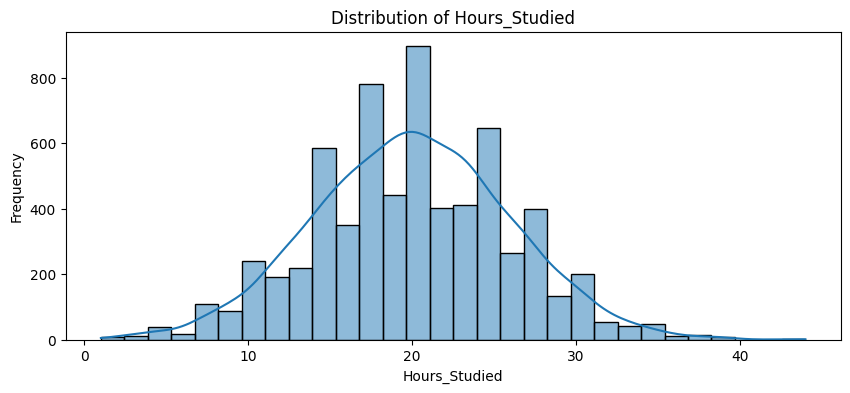

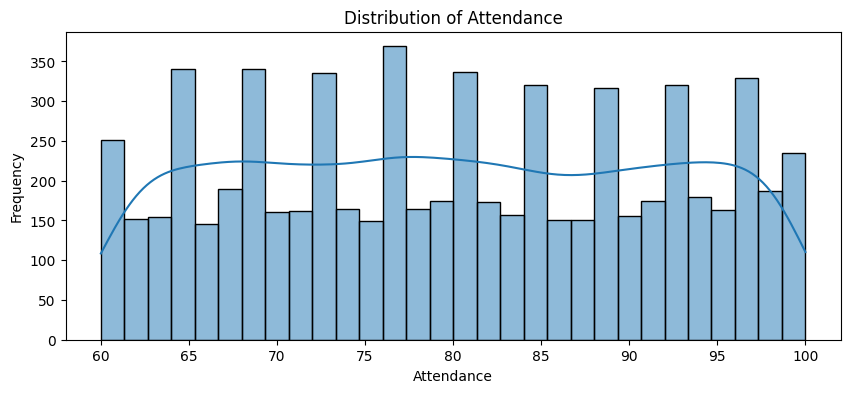

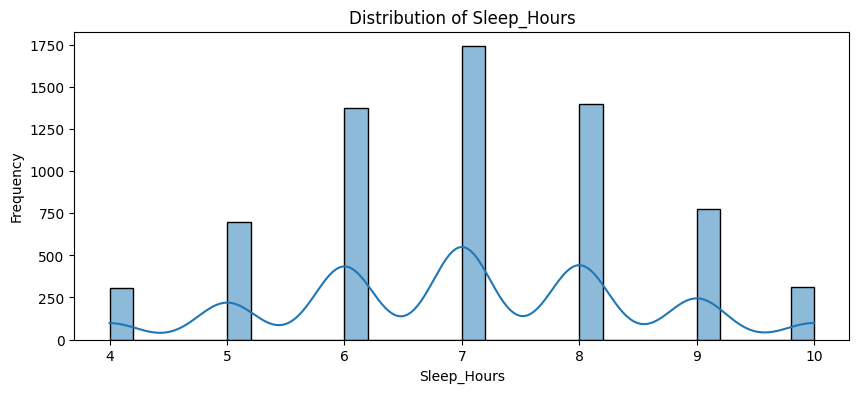

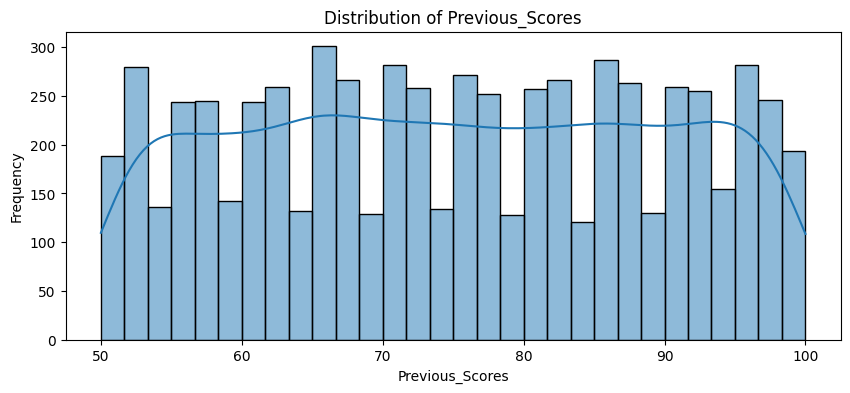

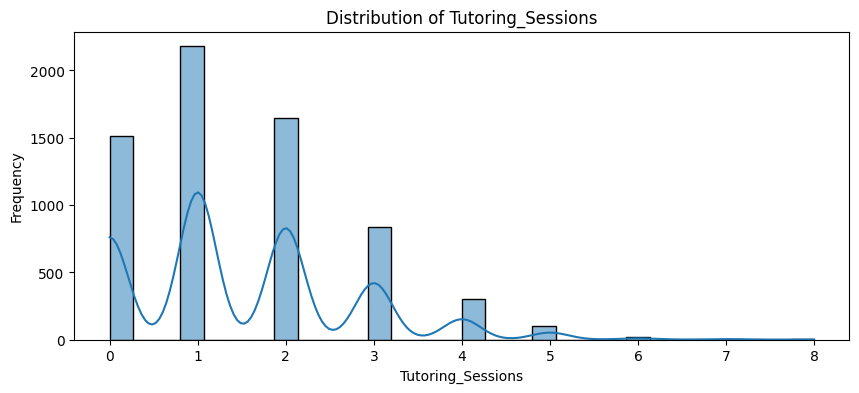

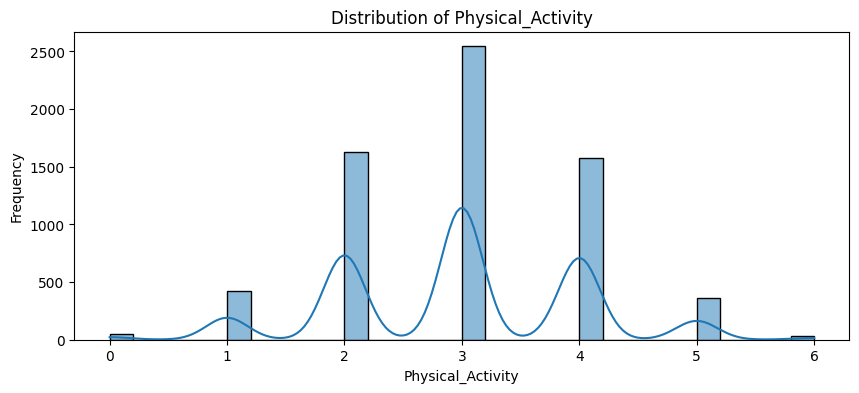

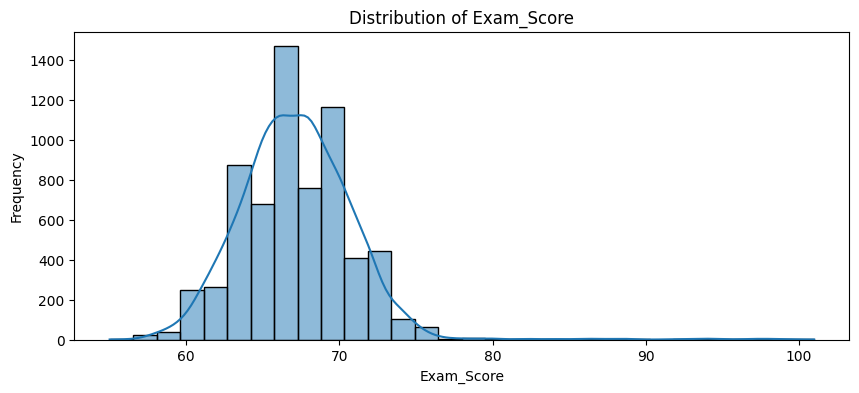

In [54]:
for col in numerical_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

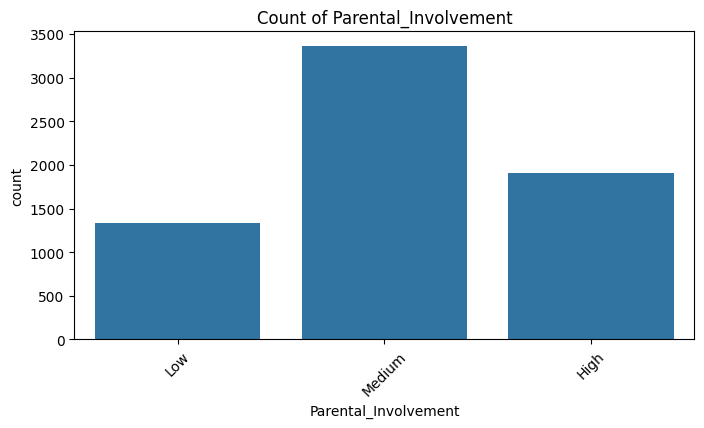

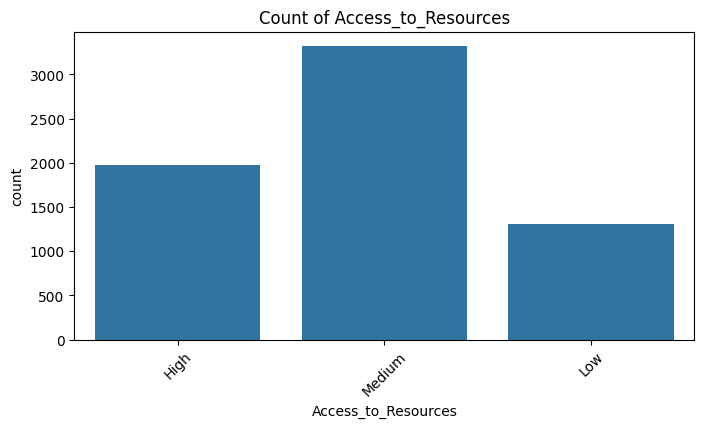

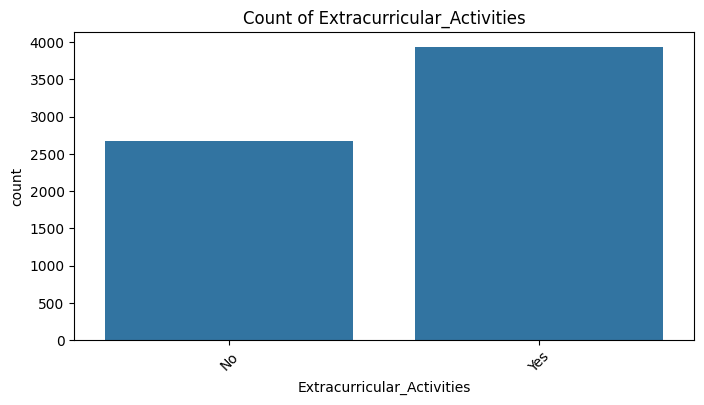

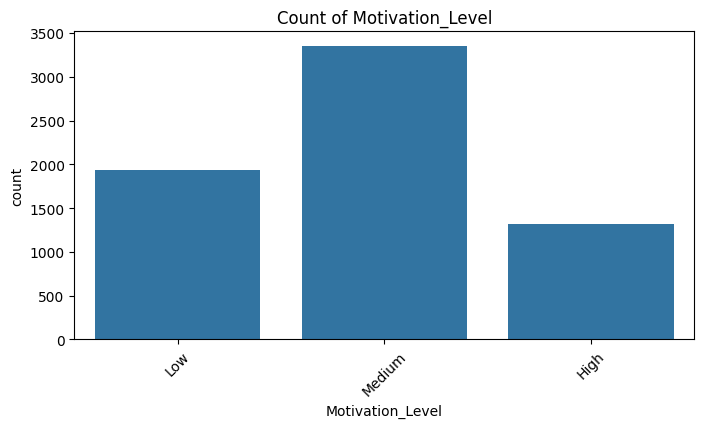

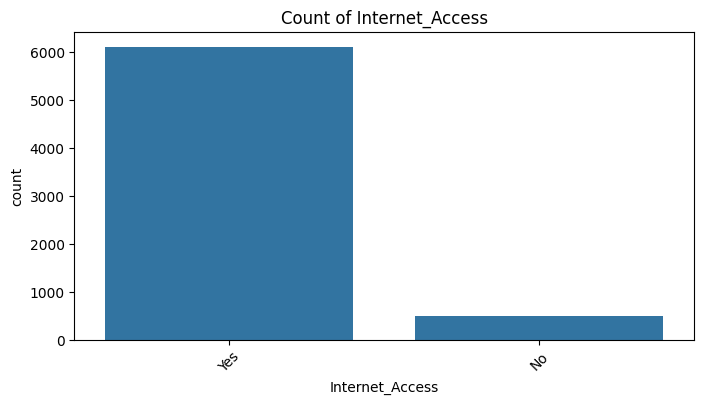

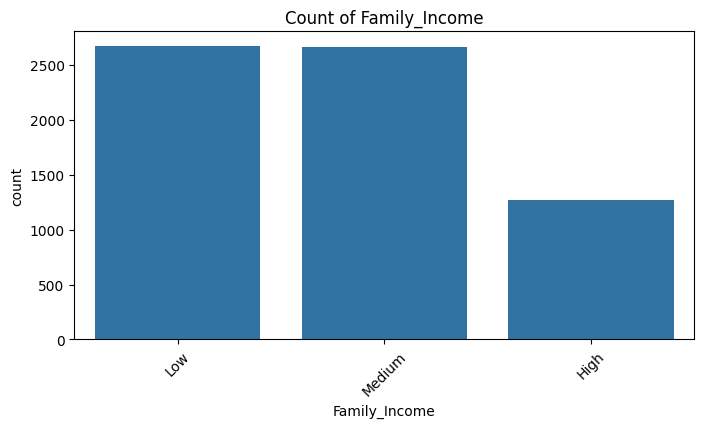

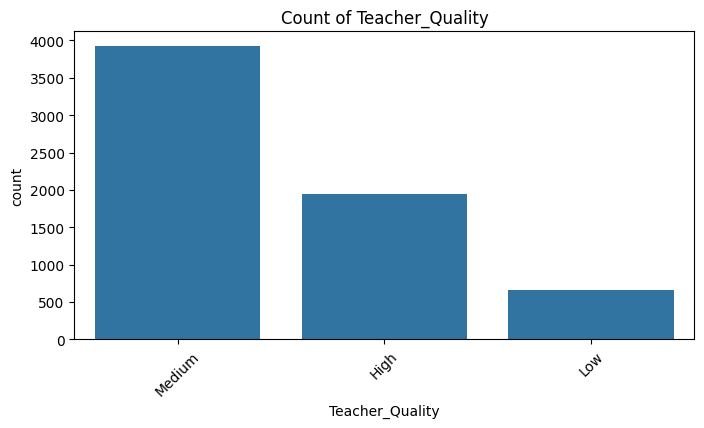

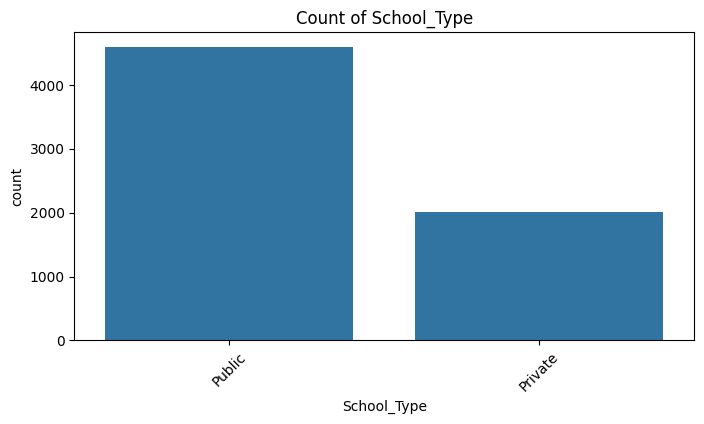

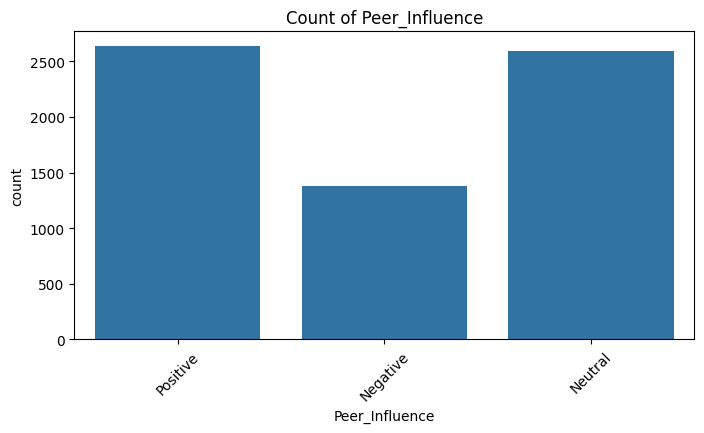

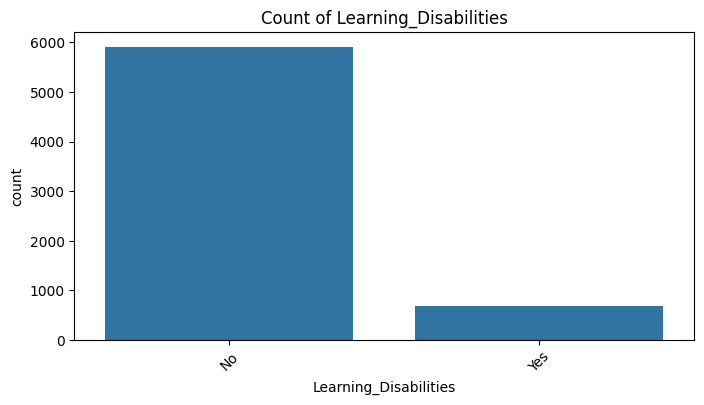

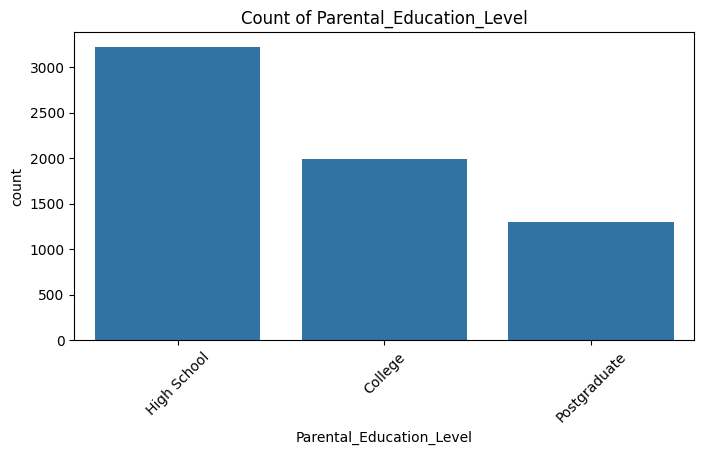

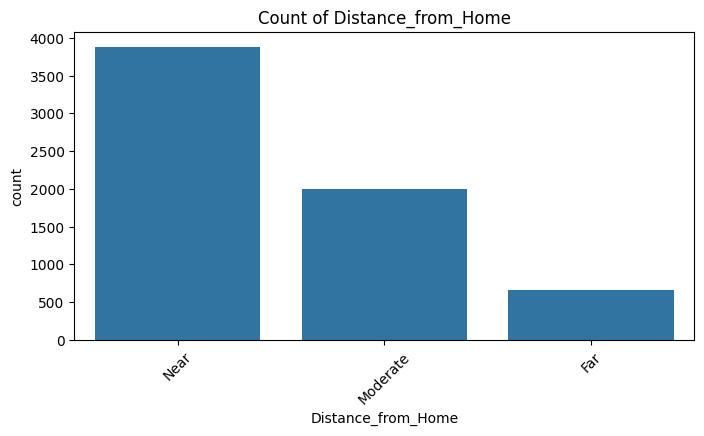

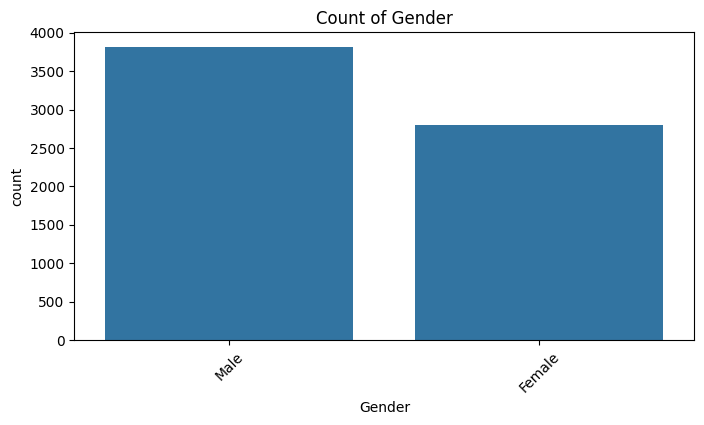

In [55]:
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()



---

cheaking linearty between label and features

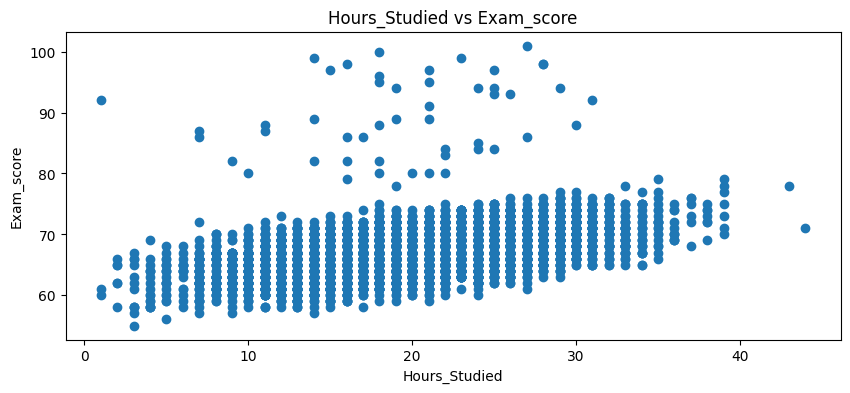

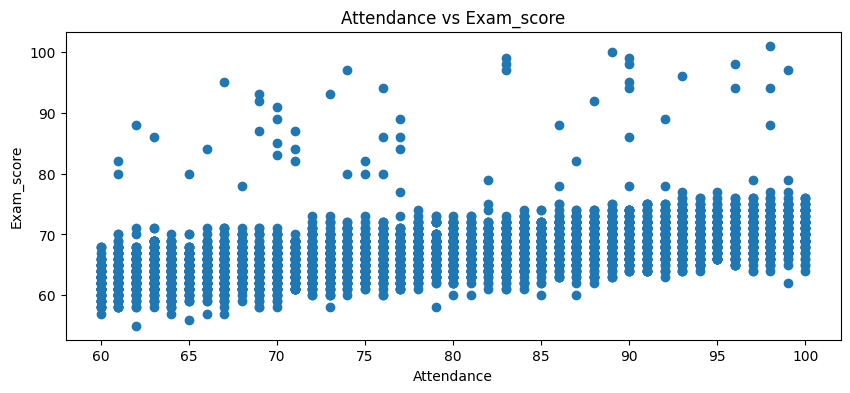

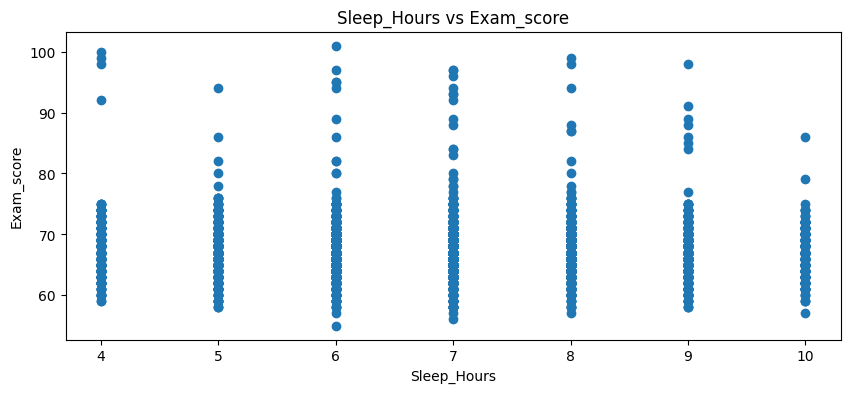

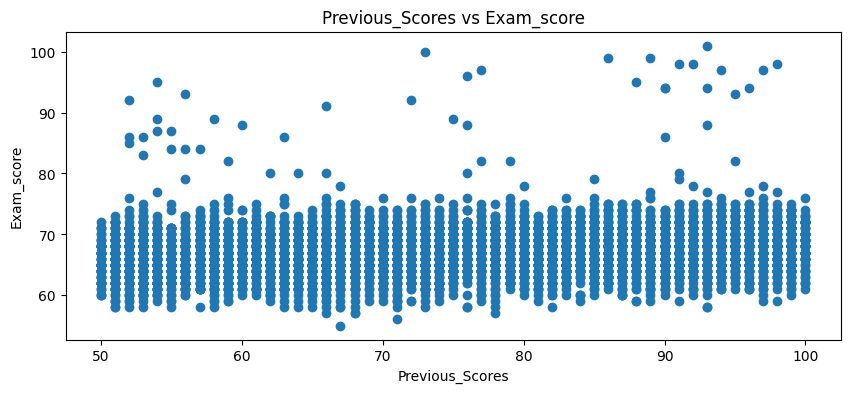

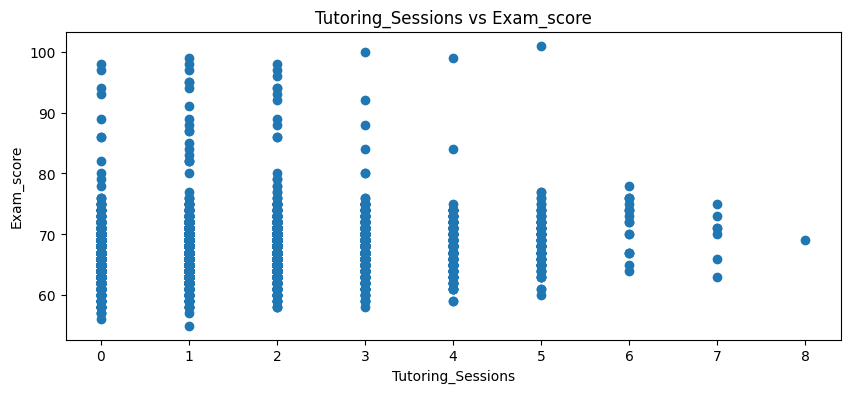

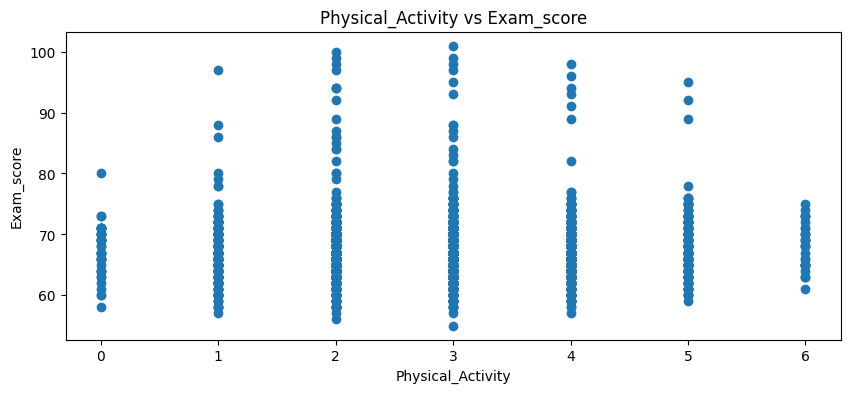

In [56]:
# graph each column in numerical_columns with Exam_score as a scater plot
for col in numerical_columns[:-1]:
    plt.figure(figsize=(10, 4))
    plt.scatter(df[col], df['Exam_Score'])
    plt.title(f'{col} vs Exam_score')
    plt.xlabel(f'{col}')
    plt.ylabel('Exam_score')
    plt.show()



## 📊 Plotting Features vs. Label  

Before training a regression model, it is useful to **visualize each feature against the target label**.  

- 📈 If the relationship looks **linear (points roughly follow a line/trend)**, then the feature is a good candidate for **Linear Regression**.  
- 🔀 If the relationship is **non-linear or scattered**, linear regression may not capture it well, and other models (polynomial regression, tree-based methods, etc.) may perform better.  
- 🎯 These plots help us **understand feature importance** and decide whether a single feature is enough or if multiple features are needed for better accuracy.  

👉 In short: plotting each feature against the label helps us **check linearity** and guides us in choosing the right regression approach.


---




## 📌Encoding  

Most machine learning models can only work with **numerical data**.  
This means any **categorical features** (like gender, color, city, etc.) must be **encoded** before training.  

- 🔢 **Label Encoding** assigns each category an integer value.  
- 🔲 **One-Hot Encoding** creates binary columns for categories (0/1).  

✅ Encoding is a **must** step — without it, models cannot interpret text-based or categorical features properly.  


In [57]:
def auto_encode_dataframe(df: pd.DataFrame):
    df_encoded = df.copy()
    le = LabelEncoder()

    for col in df.select_dtypes(include=['object']).columns:
        unique_vals = df_encoded[col].dropna().unique()
        col_idx = df_encoded.columns.get_loc(col)  # get original position

        # Case 1: Binary categorical → One-Hot Encoding (1 column only)
        if len(unique_vals) == 2:
            dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
            df_encoded.drop(col, axis=1, inplace=True)
            for i, new_col in enumerate(dummies.columns):
                df_encoded.insert(col_idx + i, new_col, dummies[new_col])

        # Case 2: More than 2 categories → Label Encoding
        else:
            df_encoded[col] = df_encoded[col].astype(str)
            df_encoded[col] = le.fit_transform(df_encoded[col])

    return df_encoded

df_encoded = auto_encode_dataframe(df)
df_encoded.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities_Yes,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access_Yes,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type_Public,Peer_Influence,Physical_Activity,Learning_Disabilities_Yes,Parental_Education_Level,Distance_from_Home,Gender_Male,Exam_Score
0,23,84,1,0,False,7,73,1,True,0,1,2,True,2,3,False,1,2,True,67
1,19,64,1,2,False,8,59,1,True,2,2,2,True,0,4,False,0,1,False,61
2,24,98,2,2,True,7,91,2,True,2,2,2,True,1,4,False,2,2,True,74
3,29,89,1,2,True,8,98,2,True,1,2,2,True,0,4,False,1,1,True,71
4,19,92,2,2,True,6,65,2,True,3,2,0,True,1,4,False,0,2,False,70


## 📌 About the `auto_encode_dataframe` Function

The `auto_encode_dataframe` function is a custom preprocessing tool that automatically encodes categorical columns in a DataFrame, making the dataset ready for machine learning.  

### 🔎 How it works:
1. Makes a copy of the input DataFrame.  
2. Loops through all **categorical (object-type)** columns.  
3. For each column:  
   - **Binary categories (2 unique values):**  
     → Applies **One-Hot Encoding** (creates 1 new binary column, dropping the first to avoid redundancy).  
     *Example:* `"Male/Female"` → `Gender_Male` (0 or 1).  
   - **More than 2 categories:**  
     → Applies **Label Encoding** (converts categories into integers).  
     *Example:* `"Red, Green, Blue"` → `0, 1, 2`.  
4. Preserves the original column order.  
5. Returns the fully encoded DataFrame (numeric-only).  

### ✅ Why it’s useful:
- Simplifies preprocessing by handling binary and multi-class features automatically.  
- Ensures machine learning algorithms can work with categorical data.  
- Keeps binary encoding compact (only 1 column).  

⚠️ **Note:** Label Encoding is fine for tree-based models (Random Forest, XGBoost, etc.), but for linear models or distance-based models, One-Hot Encoding is usually preferred for multi-class features.  


## Data cleaning


---



cheack for any missing data


*   if any missing data use


```
data.dropna(axis=0,inplace=True)
```





In [61]:
df_encoded.shape

(6607, 20)

In [62]:
#cheaking for any missing data
df_encoded.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities_Yes,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access_Yes,0
Tutoring_Sessions,0


clear outliers

In [64]:
Q1 = df_encoded[numerical_columns].quantile(0.25)
Q3 = df_encoded[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

outlier_condition = ((df_encoded[numerical_columns] < (Q1 - 1.5 * IQR)) | (df_encoded[numerical_columns] > (Q3 + 1.5 * IQR)))
outliers_iqr = outlier_condition.any(axis=1)
print(f'Number of outlier rows using IQR: {np.sum(outliers_iqr)}')

Number of outlier rows using IQR: 553


In [65]:
#remove the outlier
df_cleaned = df_encoded[~outliers_iqr]

In [67]:
Q1 = df_cleaned[numerical_columns].quantile(0.25)
Q3 = df_cleaned[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

outlier_condition = ((df_cleaned[numerical_columns] < (Q1 - 1.5 * IQR)) | (df_cleaned[numerical_columns] > (Q3 + 1.5 * IQR)))
outliers_iqr = outlier_condition.any(axis=1)
print(f'Number of outlier rows using IQR: {np.sum(outliers_iqr)}')

Number of outlier rows using IQR: 0


In [66]:
df_cleaned.shape

(6054, 20)

## simple linear regression

In [93]:
x = df_cleaned[['Hours_Studied']]
y = df_cleaned['Exam_Score']

#splite the data to train and test
x_simple_train, x_simple_test, y_simple_train, y_simple_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [94]:
model = LinearRegression()
model.fit(x_simple_train, y_simple_train)
y_test_pred = model.predict(x_simple_test)

evaluate the model

In [95]:
#compare the model prediction vs actual values in a table
pd.DataFrame({'Actual': y_simple_test, 'Predicted': y_test_pred})

,Actual,Predicted
6003,68,66.130030
652,70,66.409153
2909,65,69.200384
3375,67,65.292660
3143,61,65.850907
...,...,...
3099,67,67.804769
5538,67,65.013537
3078,66,67.246522
2559,72,68.642138


In [96]:
mae_simple = mean_absolute_error(y_simple_test, y_test_pred)
mse_simple = mean_squared_error(y_simple_test, y_test_pred)
rmse_simple = np.sqrt(mse_multi)
r2_simple = r2_score(y_simple_test, y_test_pred)

print("Multiple Linear Regression Performance:")
print("MAE:", mae_simple)
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R² Score:", r2_simple)

Multiple Linear Regression Performance:
MAE: 2.2520826164008
MSE: 7.436460425719329
RMSE: 1.1310714874628849
R² Score: 0.25855737303333026


In [78]:
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

Intercept (b0): 61.38493624386843
Slope (b1): 0.27912314648185393


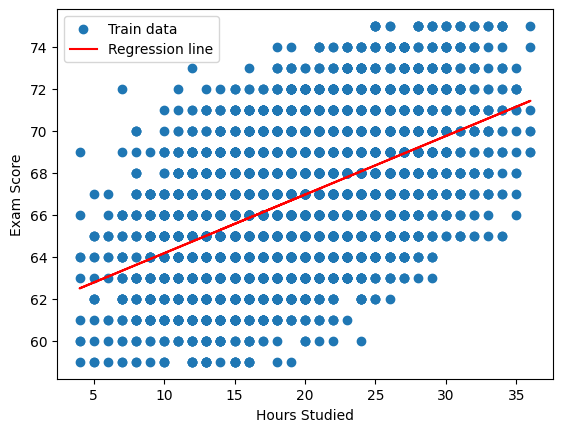

In [80]:
plt.scatter(x_simple_train, y_simple_train, label="Train data")
plt.plot(x_simple_train, model.predict(x_simple_train), color="red", label="Regression line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

## multiple linear regression

In [81]:
#make x equal all coulmns except Exam_Score to be used as label
x_multi = df_cleaned.drop('Exam_Score', axis=1)
y_multi = df_cleaned['Exam_Score']

#splite the data to train and test
x_multi_train, x_multi_test, y_multi_train, y_multi_test = train_test_split(x_multi, y_multi, test_size=0.2, random_state=42)

In [82]:
model = LinearRegression()
model.fit(x_multi_train, y_multi_train)
y_test_pred = model.predict(x_multi_test)

In [83]:
pd.DataFrame({'Actual': y_multi_test, 'Predicted': y_test_pred})

,Actual,Predicted
6003,68,66.763811
652,70,69.203131
2909,65,66.677456
3375,67,65.674985
3143,61,61.567189
...,...,...
3099,67,66.986244
5538,67,67.226758
3078,66,64.115530
2559,72,72.589094


In [84]:
mae_multi = mean_absolute_error(y_multi_test, y_test_pred)
mse_multi = mean_squared_error(y_multi_test, y_test_pred)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_multi_test, y_test_pred)

print("Multiple Linear Regression Performance:")
print("MAE:", mae_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R² Score:", r2_multi)

Multiple Linear Regression Performance:
MAE: 0.9092540651022174
MSE: 1.2793227097515028
RMSE: 1.1310714874628849
R² Score: 0.8724467910330445


In [87]:
#show model coffe for each featuer in a table
pd.DataFrame({'Feature': x_multi.columns, 'Coefficient': model.coef_})


,Feature,Coefficient
0,Hours_Studied,0.291062
1,Attendance,0.199215
2,Parental_Involvement,-0.408156
3,Access_to_Resources,-0.397807
4,Extracurricular_Activities_Yes,0.493427
5,Sleep_Hours,0.001517
6,Previous_Scores,0.048798
7,Motivation_Level,-0.130086
8,Internet_Access_Yes,1.023635
9,Tutoring_Sessions,0.501243


## polinomial regression

In [89]:
#make x equal all coulmns except Exam_Score to be used as label
x_poly = df_cleaned.drop('Exam_Score', axis=1)
y_poly = df_cleaned['Exam_Score']

#splite the data to train and test
x_poly_train, x_poly_test, y_poly_train, y_poly_test = train_test_split(x_poly, y_poly, test_size=0.2, random_state=42)

In [90]:
# polynomial regression
poly = PolynomialFeatures(degree=2)
x_poly_train_poly = poly.fit_transform(x_poly_train)
x_poly_test_poly = poly.transform(x_poly_test)

# Linear Regression on Polynomial Features
model = LinearRegression()
model.fit(x_poly_train_poly, y_poly_train)
y_test_pred = model.predict(x_poly_test_poly)

In [91]:
mae_poly = mean_absolute_error(y_poly_test, y_test_pred)
mse_poly = mean_squared_error(y_poly_test, y_test_pred)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_poly_test, y_test_pred)

print("Multiple Linear Regression Performance:")
print("MAE:", mae_poly)
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R² Score:", r2_poly)

Multiple Linear Regression Performance:
MAE: 0.3608503259421933
MSE: 0.2226322109434413
RMSE: 0.47183917911025713
R² Score: 0.977802744601665


## Comparison between models perfomences

In [97]:
# Create a dictionary to store the performance metrics
performance_metrics = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Polynomial Regression'],
    'MAE': [mae_simple, mae_multi, mae_poly],
    'MSE': [mse_simple, mse_multi, mse_poly],
    'RMSE': [rmse_simple, rmse_multi, rmse_poly],
    'R² Score': [r2_simple, r2_multi, r2_poly]
}

# Create a pandas DataFrame from the dictionary
performance_df = pd.DataFrame(performance_metrics)

# Display the DataFrame
display(performance_df)

,Model,MAE,MSE,RMSE,R² Score
0,Simple Linear Regression,2.252083,7.436460,1.131071,0.258557
1,Multiple Linear Regression,0.909254,1.279323,1.131071,0.872447
2,Polynomial Regression,0.360850,0.222632,0.471839,0.977803


## 📊 Model Comparison & Conclusions  

We tested three regression models to predict student performance and compared them using **MAE, MSE, RMSE, and R² Score**.  

---

### 🔹 Simple Linear Regression (single feature)  
- **MAE = 2.25, MSE = 7.43, RMSE = 1.13, R² = 0.26**  
- This model uses only one predictor (e.g., hours studied).  
- The R² score of **0.26** means it explains only **26% of the variance** in student performance.  
- ❌ Very weak → student performance cannot be explained by one factor alone.  

---

### 🔹 Multiple Linear Regression (all features)  
- **MAE = 0.91, MSE = 1.28, RMSE = 1.13, R² = 0.87**  
- By including **all features** (such as study time, attendance, past grades, etc.), the model performance improves drastically.  
- The R² score of **0.87** means it explains **87% of the variance**.  
- ✅ This shows that **multiple factors contribute to student performance**, and the model captures these relationships well.  

---

### 🔹 Polynomial Regression (degree = 2, multiple features)  
- **MAE = 0.36, MSE = 0.22, RMSE = 0.47, R² = 0.98**  
- By adding **polynomial terms** (squared and interaction features), the model can capture **non-linear patterns** in the data.  
- The R² score of **0.98** means it explains **98% of the variance**, with very low errors.  
- ⭐ This is the **best performing model** because it not only accounts for multiple factors but also their **non-linear relationships** (e.g., how study time and sleep might interact).  

---

### ✅ Final Conclusion  
- **Polynomial Regression (degree=2 with multiple features)** gives the best results → lowest errors and highest accuracy.  
- **Multiple Linear Regression** already performs very well and is simpler to interpret, but slightly less accurate.  
- **Simple Linear Regression** is insufficient, since performance depends on more than just one variable.  
- Overall, these results suggest that **student performance is influenced by multiple factors and their interactions**, not just a single feature in a linear way.  

---

📌 **Next Step Suggestion:**  
For presentation, we can also add:  
- A **Predicted vs Actual values plot** to visualize accuracy.  
- A **Residuals plot** to check for bias or remaining patterns in errors.  
